In [22]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import powerlaw
import scienceplots

# plt.style.use(['nature','no-latex'])

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs

In [23]:
f = 't50_a10'
path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f+'/'
full_d = np.array([])
full_l = np.array([])
mean_4_length = np.array([])
median_4_length = np.array([])
mean_lessthan_4_length = np.array([])
median_lessthan_4_length = np.array([])

cities = os.listdir(path)
# --- Degree Distribution ---

for city in cities:
    d = np.load(path+city)
    full_d = np.append(full_d, d['degree'])
    full_l = np.append(full_l, d['length'])
    mean_4_length = np.append(mean_4_length, np.mean(d['length'][d['degree'] == 4]))
    median_4_length = np.append(median_4_length, np.median(d['length'][d['degree'] == 4]))
    mean_lessthan_4_length = np.append(mean_lessthan_4_length, np.mean(d['length'][d['degree'] < 4]))
    median_lessthan_4_length = np.append(median_lessthan_4_length, np.median(d['length'][d['degree'] < 4]))

In [24]:
np.median(median_lessthan_4_length)
np.mean(mean_lessthan_4_length)

np.float64(76.12741437448715)

In [25]:
len(cities)

97

In [26]:
# counts, bin_edges = np.histogram(data, bins=np.logspace(np.log10(data.min()), np.log10(data.max()), 30))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center')
# plt.xscale('log')
# plt.yscale('log')
# plt.axvline(np.mean(data), color='red', linestyle='--', label=f'Mean: {np.mean(data):.2f}')
# plt.axvline(np.median(data), color='orange', linestyle='--', label=f'Median: {np.median(data):.2f}')
# plt.legend()
# plt.xlabel('Length L')
# plt.ylabel('Count')
# plt.title('Distribution of L for degree K = 4')
# plt.show()

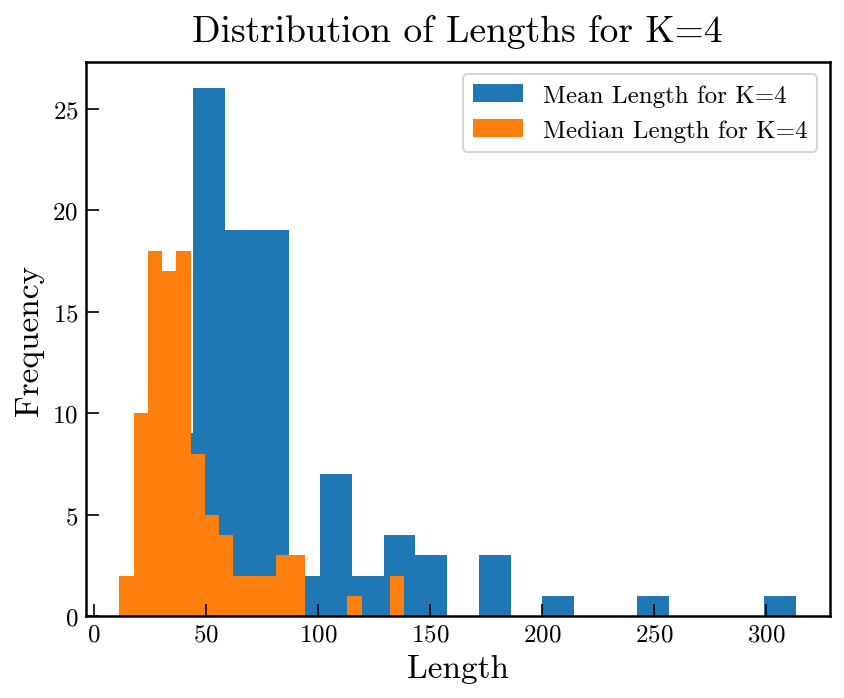

In [27]:
plt.figure()

counts, bin_edges = np.histogram(mean_4_length,  20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center', label='Mean Length for K=4')

counts, bin_edges = np.histogram(median_4_length,  20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center', label='Median Length for K=4')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('Distribution of Lengths for K=4')
plt.legend()

plt.show()

median of medians of city

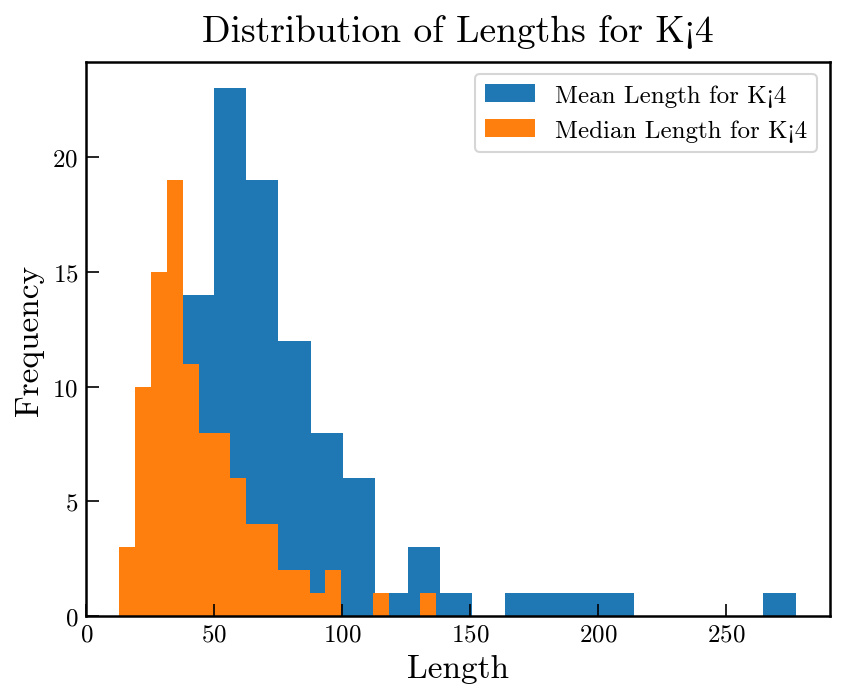

In [28]:
plt.figure()

counts, bin_edges = np.histogram(mean_lessthan_4_length,  20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center', label='Mean Length for K<4')

counts, bin_edges = np.histogram(median_lessthan_4_length,  20)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center', label='Median Length for K<4')

plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('Distribution of Lengths for K<4')
plt.legend()

plt.show()

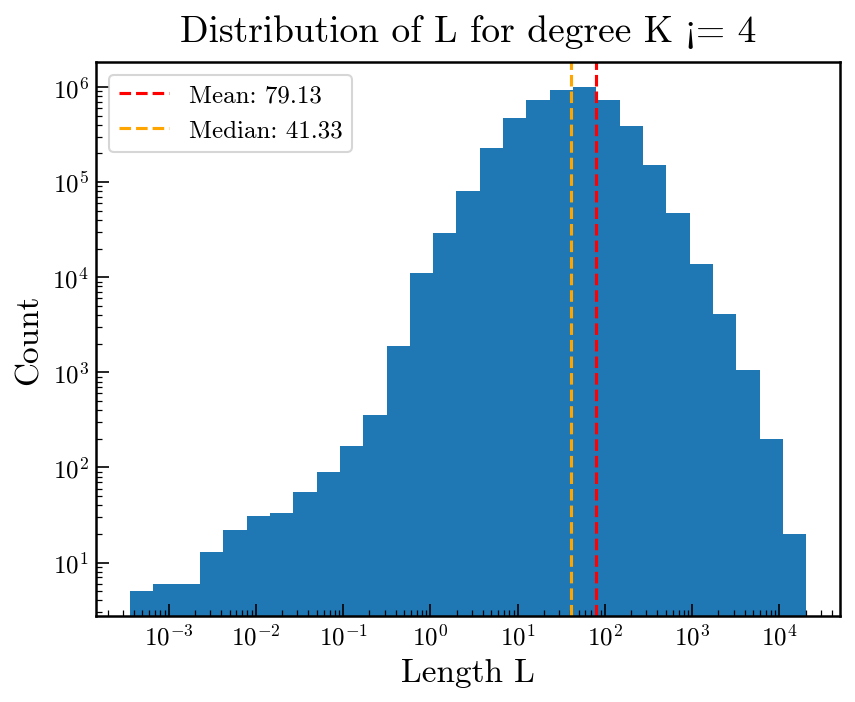

In [29]:
plt.figure()

data = full_l[full_d <= 4]
counts, bin_edges = np.histogram(data, bins=np.logspace(np.log10(data.min()), np.log10(data.max()), 30))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center')
plt.xscale('log')
plt.yscale('log')
plt.axvline(np.mean(data), color='red', linestyle='--', label=f'Mean: {np.mean(data):.2f}')
plt.axvline(np.median(data), color='orange', linestyle='--', label=f'Median: {np.median(data):.2f}')
plt.legend()
plt.xlabel('Length L')
plt.ylabel('Count')
plt.title('Distribution of L for degree K <= 4')
plt.show()

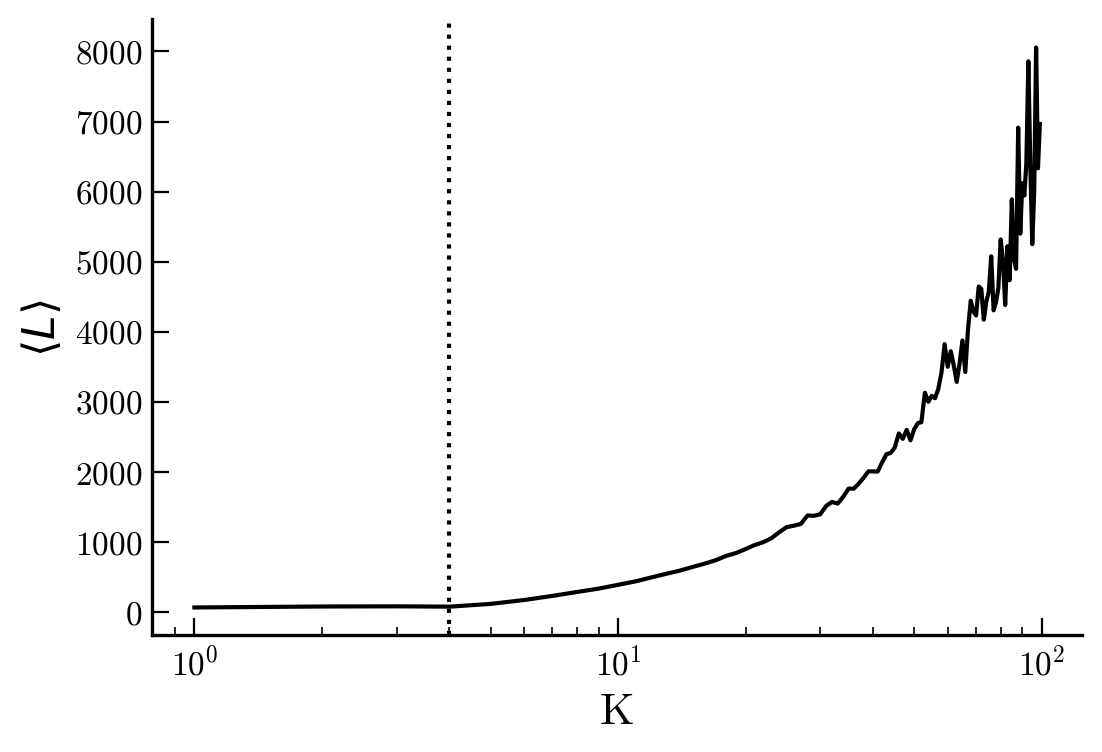

In [47]:
lengths_by_degree_median = {}
lengths_by_degree_mean = {}
std_by_degree = {}

for k in range(1,100):
    data = full_l[full_d == k]
    if len(data) > 0:
        lengths_by_degree_median[k] = np.median(data)
        lengths_by_degree_mean[k] = np.mean(data)
        std_by_degree[k] = np.std(data)


fig, ax = plt.subplots(figsize=(6, 4),dpi=200)
# plt.plot(list(lengths_by_degree_median.keys()), list(lengths_by_degree_median.values()), marker='o', label='Median')
plt.plot(list(lengths_by_degree_mean.keys()), list(lengths_by_degree_mean.values()), marker='None',color='k')


plt.xlabel('K')
plt.ylabel(r'$\langle L \rangle$')
# ax.set_title("A", loc='left', pad=20)
# Hide top/right spines (Nature style)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.axvline(4, color='k', linestyle='dotted', label=r'$\phi = $' + str(4),zorder=-1)
plt.xscale('log')
# plt.grid(True, which="both", ls="--")
# plt.legend()
plt.show()